<a href="https://colab.research.google.com/github/Sajina-S/fraud-detection-bank-payments/blob/main/DeepLearning_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/nithinganesh1/Deep_Learning_Projects.git

Cloning into 'Deep_Learning_Projects'...
remote: Enumerating objects: 1017, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 1017 (delta 6), reused 8 (delta 1), pack-reused 996 (from 1)
Receiving objects: 100% (1017/1017), 252.75 MiB | 16.97 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Updating files: 100% (974/974), done.


In [2]:
cd /content/Deep_Learning_Projects/Image_Classification

/content/Deep_Learning_Projects/Image_Classification


In [3]:
import tensorflow as tf
import os

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
import cv2
import imghdr

/tmp/ipykernel_2767/4232469594.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [6]:
ls

'Animation - 1708958036539.json'   ImageClassification.ipynb   requirements.txt
 app.py                            image_classifier_models/    sadimg2.jpg
 data/                             istock-508455188.jpg        sadimg.jpg
'happy image.jpg'                  logs/
 happyimg2.jpg                     Readme.md


In [7]:
data_dir = 'data'

In [8]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [10]:
for image_class in os.listdir(data_dir):
  for image in os.listdir(os.path.join(data_dir, image_class)):
    image_path = os.path.join(data_dir, image_class, image)
    try:
      img = cv2.imread(image_path)
      ext = imghdr.what(image_path)
      if ext not in image_exts:
        print('image not in ext list{}'.format(image_path))
        os.remove(image_path)
    except Exception as e:
      print('Issue with image{}'.format(image_path))
      #os.remove(image_path)



In [11]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 297 files belonging to 2 classes.


In [12]:
data_iterator = data.as_numpy_iterator()

In [13]:
batch = data_iterator.next()

In [14]:
len(batch)

2

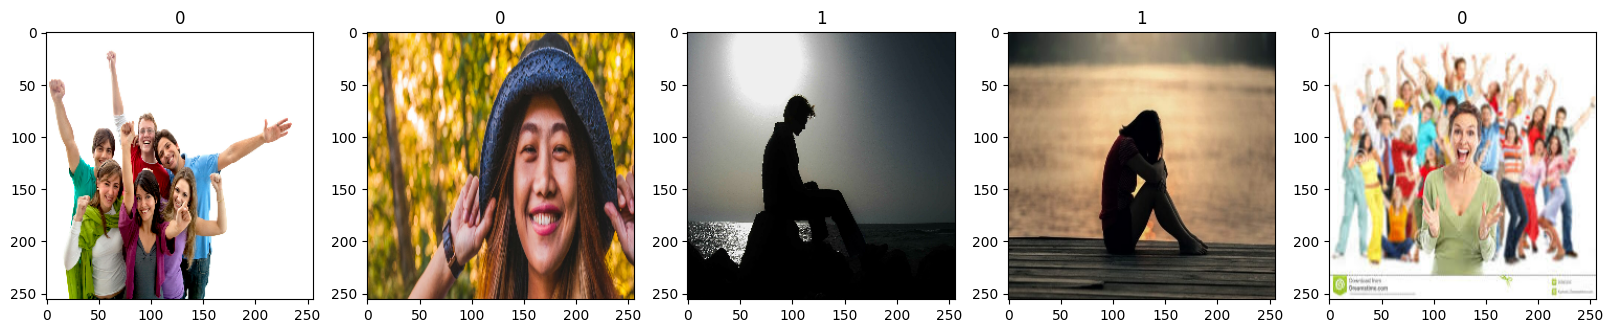

In [15]:
figure , axis = plt.subplots(ncols=5, figsize=(20,20))
for index, image in enumerate(batch[0][:5]):
  axis[index].imshow(image.astype(int))
  axis[index].title.set_text(batch[1][index])


In [16]:
data = data.map(lambda x,y : (x/255, y))

In [17]:
data.as_numpy_iterator().next()

(array([[[[0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ],
          ...,
          [0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ]],
 
         [[0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ],
          ...,
          [0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ]],
 
         [[0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ],
          ...,
          [0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ],
          [0.        , 0.00392157, 0.1254902 ]],
 
         ...,
 
         [[0.        , 0.00392157, 0.09411765],
          [0.     

In [18]:
training_data=int(len(data)*.7)
validation_data=int(len(data)*.2)
test_data=int(len(data)*.1)

In [19]:
train=data.take(training_data)
val=data.skip(training_data).take(validation_data)
test=data.skip(training_data+validation_data).take(test_data)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [21]:
model = Sequential()

In [22]:
model.add(Conv2D(16,(3,3),1,activation='relu',input_shape = (256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
logdir = 'logs'


In [26]:
tensorflow_callback=tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [27]:
hist = model.fit(train,epochs=20,validation_data=val,callbacks=[tensorflow_callback])

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5402 - loss: 0.8457 - val_accuracy: 0.5938 - val_loss: 0.6364
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6250 - loss: 0.6656 - val_accuracy: 0.7031 - val_loss: 0.6028
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6964 - loss: 0.5907 - val_accuracy: 0.8906 - val_loss: 0.5035
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.7991 - loss: 0.4651 - val_accuracy: 0.8281 - val_loss: 0.4191
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8705 - loss: 0.3601 - val_accuracy: 0.9531 - val_loss: 0.2436
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9152 - loss: 0.2695 - val_accuracy: 0.9531 - val_loss: 0.2172
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9688 - loss: 0.1753 - val_accuracy: 0.9688 - val_loss: 0.1111
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9911 - loss: 0.0807 - val_accuracy: 1.0000 - val_loss: 0.0528
Epoch 9/

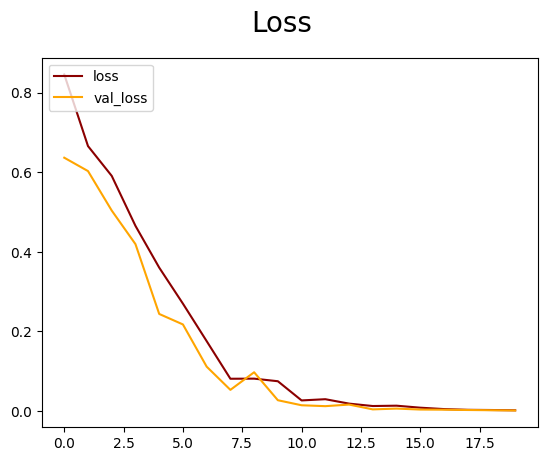

In [28]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='darkred', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

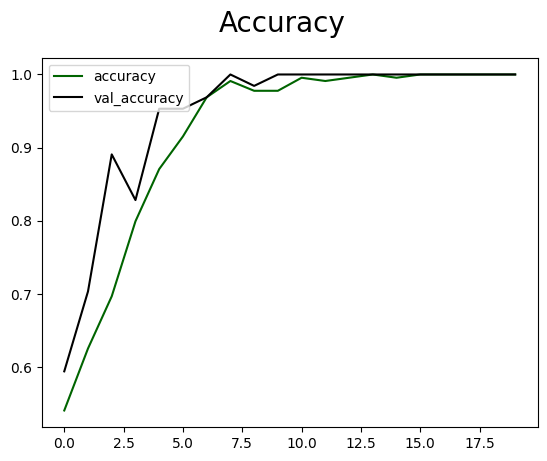

In [29]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='darkgreen', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='k', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [30]:
import cv2

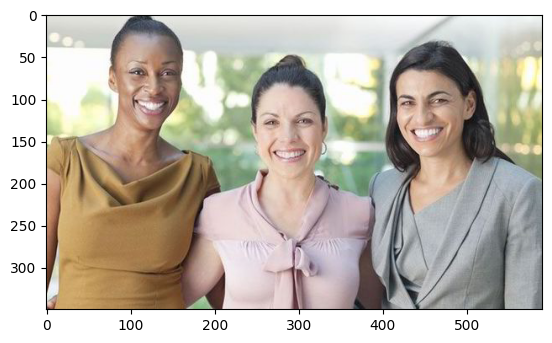

In [31]:
img = cv2.imread("data/happy/1-2.jpg")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

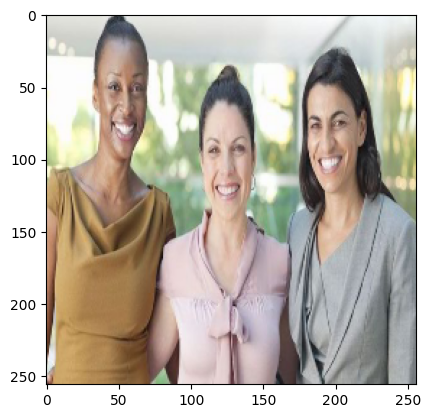

In [32]:
resize=tf.image.resize(img,(256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [33]:
y=model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


In [34]:
if y > 0.5:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


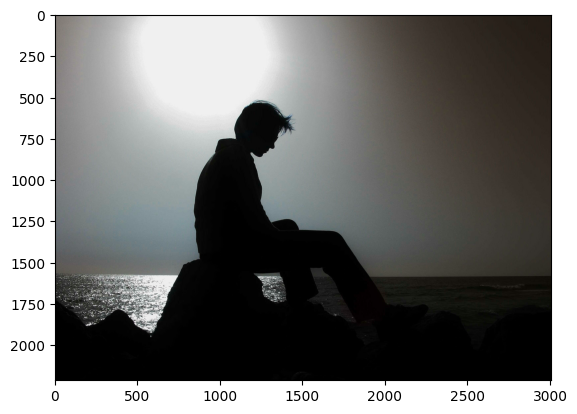

In [36]:
img = cv2.imread("data/sad/504212.jpg")
plt.imshow(img)
plt.show()

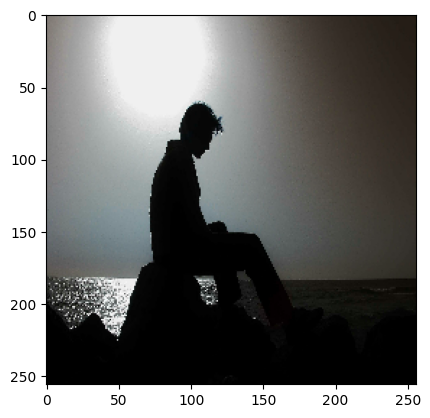

In [37]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [38]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [39]:
if yhat > 0.5:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Sad


In [40]:
model.save(os.path.join('models','image_classifier_models.h5'))